In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import yaml
from helpers.data_transforms import  load_in_data


plt.style.use("../science.mplstyle")

In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:


BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5



working_dir = "/pscratch/sd/r/rmastand/muon_collider"

In [4]:

feature_labels = ["log($E$) [Gev]", "$x$", "$y$", "$z$", "$t$ [s]", "context"]
log_vars = []



In [5]:
data_dict = {}

for col_name in ["OuterTrackerBarrelCollection", "InnerTrackerBarrelCollection", "VertexBarrelCollection"]:
    data_dict[col_name] = load_in_data([col_name], "xy", working_dir, 0.1)[0]
        

bins_dict = {
    0: np.linspace(-20, 0, NUM_BINS),
    1: np.linspace(0, 1500, NUM_BINS),
    2: np.linspace(-4, 4, NUM_BINS),
    3: np.linspace(-1500, 1500, NUM_BINS),
    4: np.linspace(-5, 25, NUM_BINS),
}

(<Figure size 2160x360 with 5 Axes>,
 array([<Axes: xlabel='log($E$) [Gev]', ylabel='Density'>,
        <Axes: xlabel='$x$'>, <Axes: xlabel='$y$'>, <Axes: xlabel='$z$'>,
        <Axes: xlabel='$t$ [s]'>], dtype=object))

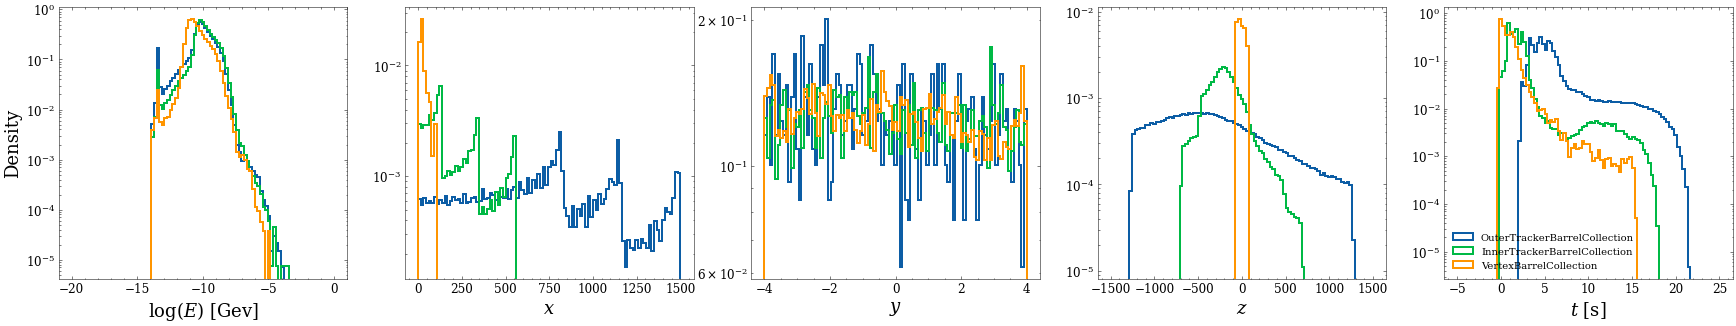

In [6]:

plot_hists_1d(data_dict, bins_dict, log_dims=log_vars, labels=feature_labels)




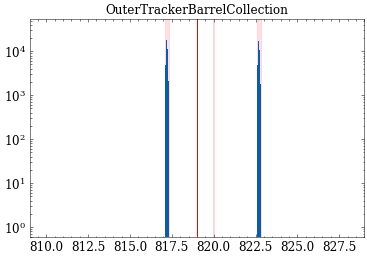

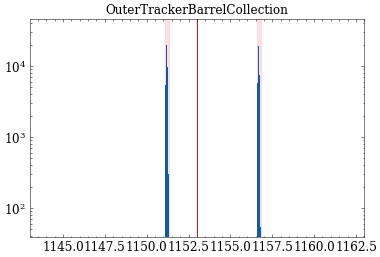

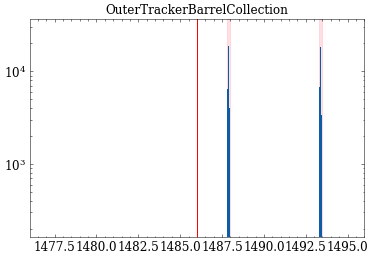

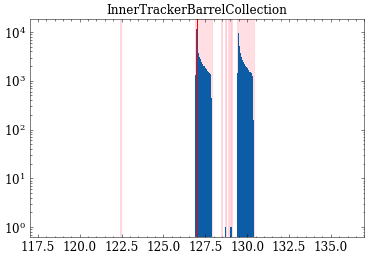

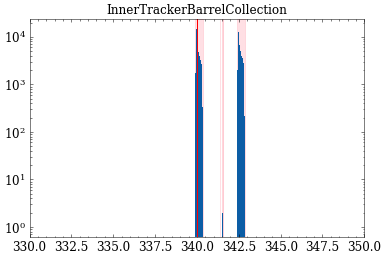

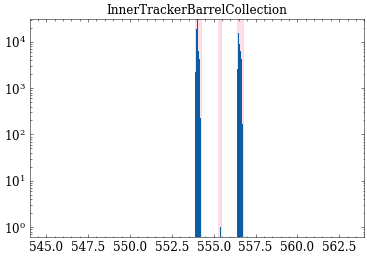

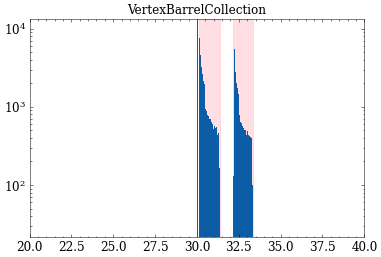

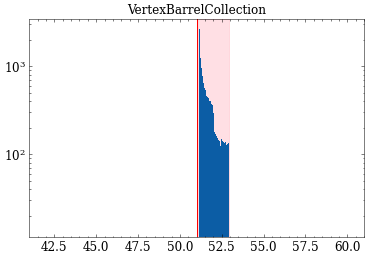

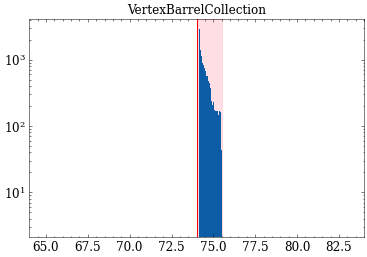

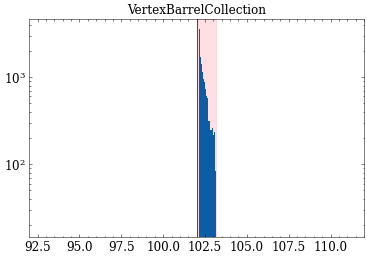

In [7]:
radii = {
    "OuterTrackerBarrelCollection": [819, 1153, 1486],
    "InnerTrackerBarrelCollection": [127, 340, 554],
    "VertexBarrelCollection": [30, 51, 74, 102],
}


mask_definitions = {
    col_name: {
        
    "lower_bounds":[],
    "upper_bounds":[],
}              
   for col_name in data_dict.keys() 
                   }


for col_name in data_dict.keys():

    r = np.sqrt(data_dict[col_name][:,1]**2 + data_dict[col_name][:,2]**2)
    
    for radius in radii[col_name]:

        bins = np.linspace(radius - 10, radius + 10, 1000)
        
        hist, bin_edges = np.histogram(r, bins)

        for i in range(len(hist)-1):
            if hist[i] == 0 and hist[i+1] > 0:
                mask_definitions[col_name]["lower_bounds"].append(bin_edges[i])
            if hist[i] > 0 and hist[i+1] == 0:
                mask_definitions[col_name]["upper_bounds"].append(bin_edges[i+1])

    
        plt.figure()
        for j in range(len(mask_definitions[col_name]["lower_bounds"])):
            plt.axvspan(mask_definitions[col_name]["lower_bounds"][j], mask_definitions[col_name]["upper_bounds"][j], alpha = 0.5, color = "pink")
            
        plt.hist(r, bins = bins)
        plt.xlim([radius - 10, radius + 10])
        plt.axvline(radius, color = "r")

        plt.title(f"{col_name}")
        plt.yscale("log")
        plt.show()

In [8]:
with open("mask_definitions.pkl", "wb") as ofile:
    pickle.dump(mask_definitions, ofile)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm



def get_delta_R_neighbors(data_array, R, NN):

    x = data_array[:NN,1]
    y = data_array[:NN,2]
    z = data_array[:NN,3]

    # convert to eta, phi
    phi = np.arctan2(y, x)
    rT = np.sqrt(x**2 + y**2)
    eta = np.arcsinh(z / rT)

    N = len(eta)

    print(col_name)
    print("N =", N)

    # bin size ~ ΔR
    deta = 2*R
    dphi = 2*R

    eta_min = eta.min()
    phi_min = -np.pi

    eta_bin = np.floor((eta - eta_min) / deta).astype(int)
    phi_bin = np.floor((phi - phi_min) / dphi).astype(int)

    # build grid
    grid = {}
    for i in range(N):
        key = (eta_bin[i], phi_bin[i])
        if key not in grid:
            grid[key] = []
        grid[key].append(i)

    neighbor_counts = np.zeros(N, dtype=int)

    # search neighboring bins
    for i in tqdm(range(N)):

        eb = eta_bin[i]
        pb = phi_bin[i]

        for de in [-1,0,1]:
            for dp in [-1,0,1]:

                key = (eb+de, pb+dp)

                if key not in grid:
                    continue

                for j in grid[key]:

                    if j == i:
                        continue

                    d_eta = eta[j] - eta[i]

                    d_phi = phi[j] - phi[i]
                    d_phi = (d_phi + np.pi) % (2*np.pi) - np.pi

                    dR = np.sqrt(d_eta**2 + d_phi**2)

                    if dR < r:
                        neighbor_counts[i] += 1

    return neighbor_counts



In [ ]:
paths = {
"OuterTrackerBarrelCollection":"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/OuterTrackerBarrelCollection_NCSF_OTBC_S_2048.npy",
    "InnerTrackerBarrelCollection":"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/InnerTrackerBarrelCollection_NCSF_ITBC_S_2048.npy",
    "VertexBarrelCollection":"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/VertexBarrelCollection_NCSF_VBC_S_2048.npy",
}
for col_name in data_dict.keys():

    neighbor_counts_data = get_delta_R_neighbors(data_dict[col_name], 0.1, 100000)


    a = np.load(paths[col_name])
    neighbor_counts_flow = get_delta_R_neighbors(a, 0.1, 100000)

    max_val0 = np.max(neighbor_counts_data)
    max_val1 = np.max(neighbor_counts_flow)
    max_val = np.max([max_val0, max_val1])


    plt.figure()
    plt.hist(neighbor_counts_data, bins=np.arange(0, max_val, 1), histtype = "step", label = "data")
    plt.hist(neighbor_counts_flow, bins=np.arange(0, max_val, 1), histtype = "step", label = "flow")
    plt.legend()
    plt.xlabel("Number of neighbors within ΔR < 0.1")
    plt.ylabel("Count")
    plt.title(col_name)
    plt.show()

OuterTrackerBarrelCollection
N = 100000


 20%|██        | 20421/100000 [02:10<08:29, 156.25it/s]